In [2]:
import numpy as np
from matplotlib import pyplot as plt
import datetime
import Bayesian_Methods as Bayes
from functools import partial
import sys
import Parameters as Pars
from Full_Par_Method import Parameter_Processing
import Full_Par_Method
from multiprocess import Pool
from dynesty import DynamicNestedSampler, sampler, plotting
from getdist import plots, MCSamples

In [3]:
Data = Parameter_Processing(Full_Par_Method.FidPars, load_strain = False)
Nano_strains = Data.CharStrainBound_Nano_15()[0]
ndim = 6
par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])

In [4]:
def Likelihood_Wrapper(parameters, Data = Nano_strains):
    par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
    par_dict = {key: value for key, value in zip(par_names,parameters)}
    t1 = Parameter_Processing(par_dict, load_strain = False)
    t1.get_Strain_pdf(provide_kde = Data)
    DistObj = Bayes.Distribution(par_dict) #Initialize Distribution Object for the pre-defined parameters
    PDF = DistObj.PDF(DistObj) #Create a pdf object from the given distribution object
    PDF.get_pdf(t1.pdf, t1.hcmax)
    PDF.dim_names = np.array('Realisations') #Set the name of the dimensions of the PDF to the dimensions of holodeck
    Priors = DistObj.Priors(DistObj)
    Priors.Uniform()
    I = DistObj.MCI(Priors,PDF)  
    I.apply_prior()
    Likelihood = I.Integration('Realisations')
    return np.log10(float(Likelihood))

In [5]:
def Prior_Wrapper(u):
    par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
    return Pars.Parameter_Uniform(u,par_ranges[1],par_ranges[0])

In [6]:
s = sampler.Sampler.restore(f'Dynesty_Samples/{str(par_names)}_Full_Like_Dynamic_Parallel_64_unif_100000_50R')
dresults = s.results
names = ('$\\psi_0$','$m_{\\psi_0}$', '$\\mu$', '$\\epsilon_{\\mu}$', '$\\tau_f$','$\\nu_{inner}$')

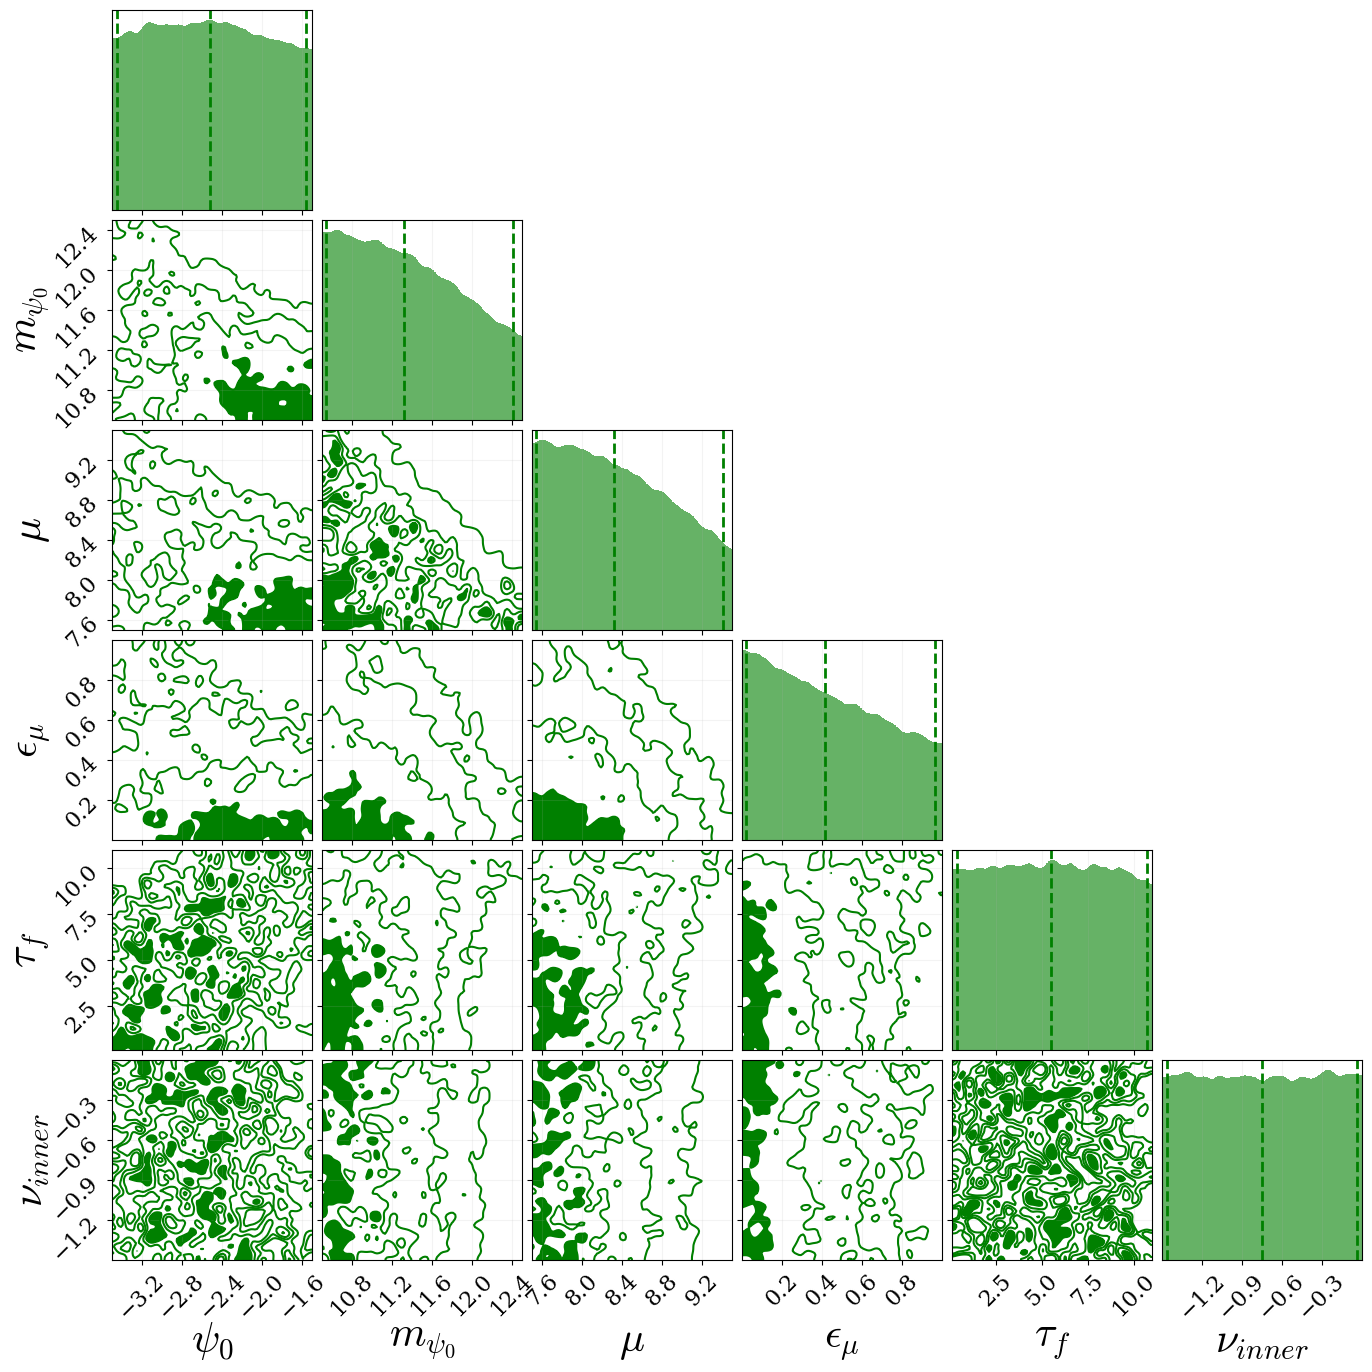

In [14]:
cfig, caxes = plotting.cornerplot(dresults, labels = names, label_kwargs= dict(fontsize=30), title_kwargs = dict(fontsize=30), show_titles=False, quantiles = [0.025,0.5,0.975], color='green')
for caxes in cfig.get_axes():
    caxes.tick_params(axis='both', labelsize=16)
plt.savefig('dynesty_corner_dynamic_sampler_full.png')